# ARCHS4 reconstruction error — saturation models, random subsamples (plots)

**Environment:** `clamp-analyses`

Loads pre-computed reconstruction error results from `02_random_saturation_reconstruction_error_compute.ipynb` and generates plots showing how reconstruction quality changes with the number of latent variables (k) at each random-subsample coverage level.

Inputs: `output/01_model_building/06_reconstruction_error/reconstruction_error_random_saturation_results.rds`

Outputs: `output/01_model_building/06_reconstruction_error/`

In [1]:
library(data.table)
library(dplyr)
library(ggplot2)
library(here)


Attaching package: ‘dplyr’




The following objects are masked from ‘package:data.table’:

    between, first, last




The following objects are masked from ‘package:stats’:

    filter, lag




The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




here() starts at /home/msubirana/Documents/pivlab/clamp-analyses



## Parameters

In [2]:
output_dir <- here("output", "01_model_building", "06_reconstruction_error")
message("Output dir: ", output_dir)

Output dir: /home/msubirana/Documents/pivlab/clamp-analyses/output/01_model_building/06_reconstruction_error



## Load results

In [3]:
results_list <- readRDS(file.path(output_dir, "reconstruction_error_random_saturation_results.rds"))
results_df   <- data.table::fread(file.path(output_dir, "reconstruction_error_random_saturation_summary.csv"))

message("Loaded ", length(results_list), " result entries")
print(results_df)

Loaded 85 result entries



    coverage_pct  seed   run          model          sampling k_target n_lvs
           <int> <int> <int>         <char>            <char>    <int> <int>
 1:            1   123     1 CLAMPfull_hall random_saturation     1296  1296
 2:            1   124     2 CLAMPfull_hall random_saturation     1296  1296
 3:            1   125     3 CLAMPfull_hall random_saturation     1296  1296
 4:            1   123     1 CLAMPfull_hall random_saturation      173   173
 5:            1   124     2 CLAMPfull_hall random_saturation      173   173
 6:            1   125     3 CLAMPfull_hall random_saturation      173   173
 7:            1   123     1 CLAMPfull_hall random_saturation      432   432
 8:            1   124     2 CLAMPfull_hall random_saturation      432   432
 9:            1   125     3 CLAMPfull_hall random_saturation      432   432
10:            1   123     1 CLAMPfull_hall random_saturation       86    86
11:            1   124     2 CLAMPfull_hall random_saturation       86    86

## Plots

In [4]:
canonical_k <- c(86, 173, 432, 864, 1296, 1728)
snap_k <- function(k) canonical_k[which.min(abs(canonical_k - k))]

coverage_order <- sort(unique(results_df$coverage_pct))
results_df$coverage_label <- factor(
  paste0(results_df$coverage_pct, "%"),
  levels = paste0(coverage_order, "%")
)
results_df$k_canonical <- sapply(results_df$k_target, snap_k)

summary_stats <- results_df %>%
  dplyr::group_by(coverage_pct, coverage_label, k_canonical) %>%
  dplyr::summarise(
    mean_median_cor = mean(median_cor),
    sd_median_cor   = sd(median_cor),
    n_runs          = dplyr::n(),
    .groups = "drop"
  )

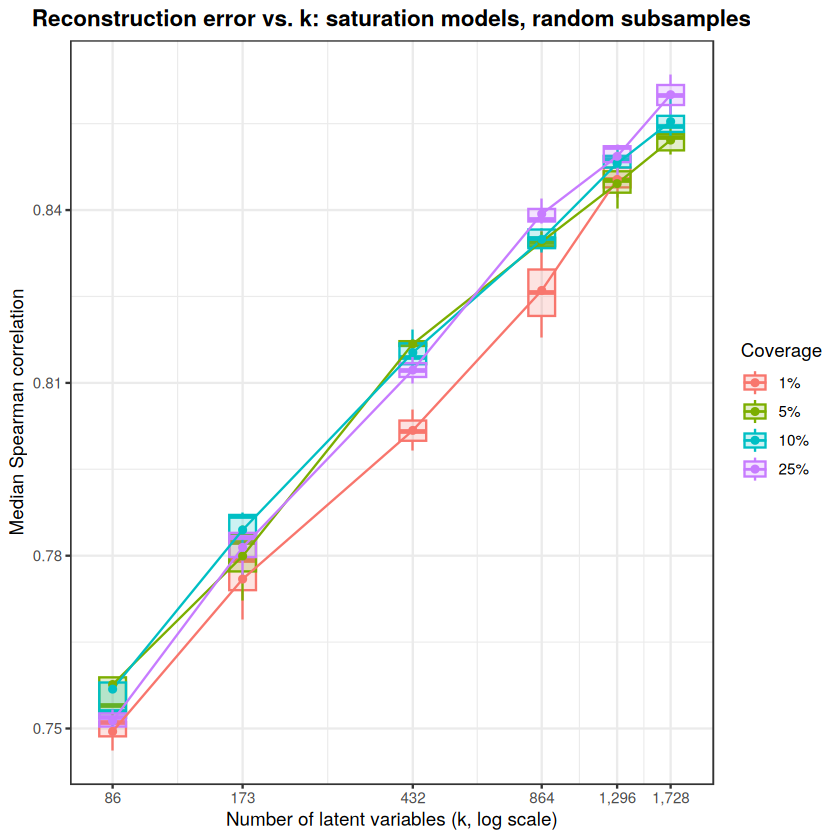

In [5]:
# Plot 1: median correlation vs k_canonical, coloured by coverage %, boxplot across seeds
box_width <- min(diff(sort(log10(canonical_k)))) * 0.5

p_line <- ggplot2::ggplot(
    results_df,
    ggplot2::aes(x = k_canonical, y = median_cor,
                 colour = coverage_label, fill = coverage_label)) +
  ggplot2::geom_boxplot(
    ggplot2::aes(group = interaction(coverage_label, k_canonical)),
    alpha = 0.2, outlier.shape = NA, width = box_width, position = "identity"
  ) +
  ggplot2::geom_line(
    data = summary_stats,
    ggplot2::aes(x = k_canonical, y = mean_median_cor, group = coverage_label)
  ) +
  ggplot2::geom_point(
    data = summary_stats,
    ggplot2::aes(x = k_canonical, y = mean_median_cor)
  ) +
  ggplot2::scale_x_continuous(
    breaks = canonical_k,
    trans  = "log10",
    labels = scales::comma
  ) +
  ggplot2::theme_bw() +
  ggplot2::labs(
    x      = "Number of latent variables (k, log scale)",
    y      = "Median Spearman correlation",
    colour = "Coverage",
    fill   = "Coverage",
    title  = "Reconstruction error vs. k: saturation models, random subsamples"
  ) +
  ggplot2::theme(plot.title = ggplot2::element_text(hjust = 0.5, face = "bold"))

p_line

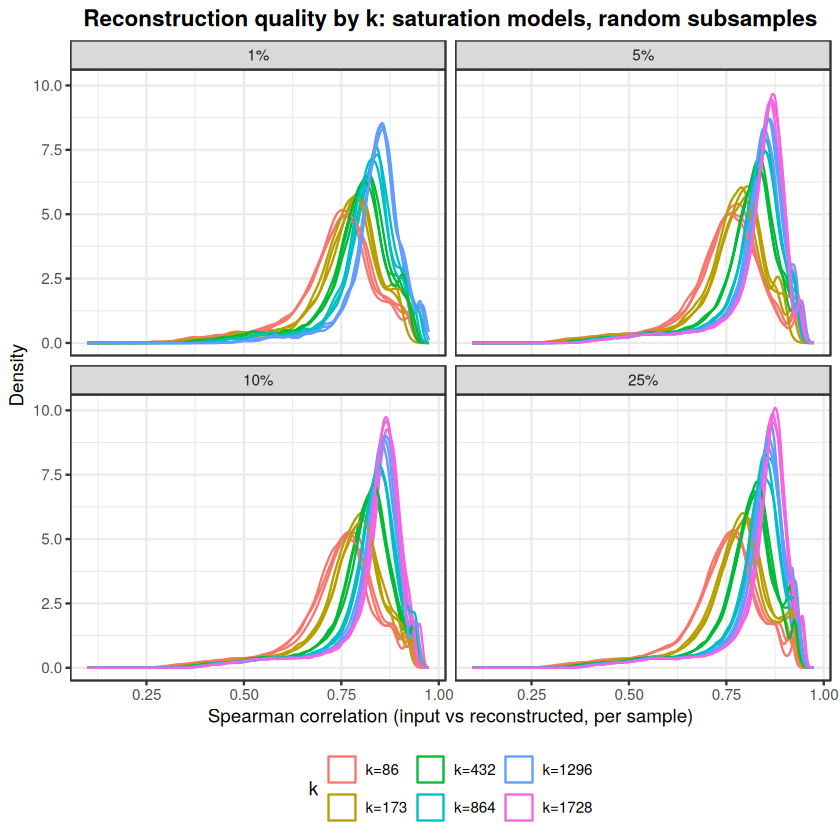

In [6]:
# Plot 2: density of per-sample Spearman cors, faceted by coverage %, coloured by k
cor_long <- dplyr::bind_rows(
  lapply(results_list, function(x) {
    data.frame(
      coverage_pct = x$coverage_pct,
      k_target     = x$k_target,
      run          = x$run,
      cor          = x$cor_vector[[1]],
      stringsAsFactors = FALSE
    )
  })
)

cor_long$coverage_label <- factor(
  paste0(cor_long$coverage_pct, "%"),
  levels = paste0(coverage_order, "%")
)
cor_long$k_canonical <- sapply(cor_long$k_target, snap_k)
cor_long$k_label <- factor(
  paste0("k=", cor_long$k_canonical),
  levels = paste0("k=", canonical_k)
)

p_density <- ggplot2::ggplot(
    cor_long,
    ggplot2::aes(x = cor, colour = k_label,
                 group = interaction(k_label, run))) +
  ggplot2::geom_density(alpha = 0.3) +
  ggplot2::facet_wrap(~ coverage_label, ncol = 2) +
  ggplot2::theme_bw() +
  ggplot2::labs(
    x      = "Spearman correlation (input vs reconstructed, per sample)",
    y      = "Density",
    colour = "k",
    title  = "Reconstruction quality by k: saturation models, random subsamples"
  ) +
  ggplot2::theme(
    plot.title      = ggplot2::element_text(hjust = 0.5, face = "bold"),
    legend.position = "bottom"
  )

p_density